# Искусственный интеллект — занятие 2
### Деревья решений

**Логика занятия:** как по данным выбрать порог разделения двух классов → как дерево выбирает признаки → обучение классификатора и разбор важности признаков.

## 1. Разделение двух классов по порогу

Есть два набора значений (`classify_sdiff.dat`). Построим кумулятивные распределения и найдём точку, где они пересекаются — это и есть порог, лучше всего разделяющий классы.

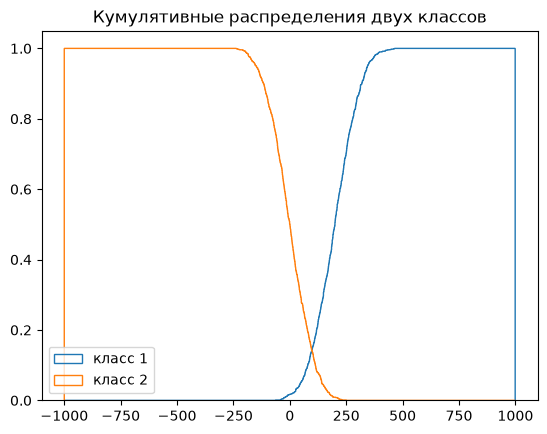

порог разделения: 107.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

j, s = [], []
with open('files/classify_sdiff.dat', 'r') as f:
    for line in f:
        if not line.strip():
            continue
        a, b = line.split()
        j.append(int(a))
        s.append(int(b))
d1, d2 = np.array(j), np.array(s)

h1 = plt.hist(d1, density=True, cumulative=True, histtype='step',
              bins=range(-1000, 1000), label='класс 1')
h2 = plt.hist(d2, density=True, cumulative=-1, histtype='step',
              bins=range(-1000, 1000), label='класс 2')
plt.legend()
plt.title('Кумулятивные распределения двух классов')
plt.show()

a1, a2, c2 = np.array(h1[0]), np.array(h2[0]), np.array(h2[1])
idx = np.argmin(a1 + a2)
print('порог разделения:', c2[idx])

## 2. Как дерево выбирает признак

На данных `binary_rules.dat` (бинарные признаки + метка) посмотрим, как меняется доля положительного класса при каждом признаке. Признак, который сильнее всего меняет долю, дерево и выбирает для разбиения.

In [2]:
d = []
with open('files/binary_rules.dat') as f:
    for line in f:
        if line.strip():
            d.append([int(x) for x in line.split()])
d = np.array(d)
X, Y = d[:, :-1], d[:, -1]

print('доля положительных (p0):', round(float(Y.mean()), 4))
for i in range(X.shape[1]):
    print(f'  признак {i} == 1 -> доля {Y[X[:, i] == 1].mean():.4f}')

доля положительных (p0): 0.245
  признак 0 == 1 -> доля 0.2296
  признак 1 == 1 -> доля 0.2557
  признак 2 == 1 -> доля 0.5000
  признак 3 == 1 -> доля 0.4960
  признак 4 == 1 -> доля 0.2626


In [3]:
Y1, X1 = Y[X[:, 2] == 1], X[X[:, 2] == 1]
print('после разбиения по признаку 2, p0:', round(float(Y1.mean()), 4))
for i in range(X1.shape[1]):
    print(f'  признак {i} == 1 -> доля {Y1[X1[:, i] == 1].mean():.4f}')

после разбиения по признаку 2, p0: 0.5
  признак 0 == 1 -> доля 0.4977
  признак 1 == 1 -> доля 0.5167
  признак 2 == 1 -> доля 0.5000
  признак 3 == 1 -> доля 1.0000
  признак 4 == 1 -> доля 0.5081


## 3. Обучение дерева решений

Обучим `DecisionTreeClassifier` на данных `unknown_data.dat.short` и посмотрим точность, важность признаков и верхние уровни дерева.

In [1]:
from sklearn.tree import DecisionTreeClassifier, export_text

d = []
with open('files/unknown_data.dat.short') as f:
    for line in f:
        if line.strip():
            d.append([float(x) for x in line.split()])
d = np.array(d)
X, y = d[:, :-1], d[:, -1]

clf = DecisionTreeClassifier(random_state=0)
clf.fit(X, y)
print('точек:', len(y), '| признаков:', X.shape[1])
print('точность на обучающей выборке:', round(clf.score(X, y), 4))
print('важность признаков:', np.round(clf.feature_importances_, 3))

точек: 100000 | признаков: 4
точность на обучающей выборке: 1.0
важность признаков: [0.602 0.307 0.017 0.074]


In [5]:
print(export_text(clf, max_depth=3))

|--- feature_0 <= 500.50
|   |--- class: 0.0
|--- feature_0 >  500.50
|   |--- feature_1 <= 300.50
|   |   |--- feature_3 <= 800.50
|   |   |   |--- class: 0.0
|   |   |--- feature_3 >  800.50
|   |   |   |--- feature_2 <= 150.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_2 >  150.50
|   |   |   |   |--- class: 1.0
|   |--- feature_1 >  300.50
|   |   |--- class: 1.0



---

**Итог.** Научились выбирать порог по кумулятивным распределениям, оценивать информативность признаков по изменению доли класса и обучать дерево решений, разбирая важность признаков.